<a href="https://colab.research.google.com/github/wvb20/cv-face-alignment/blob/main/notebooks/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction
This Colab worksheet provides a starting point for the coursework assignment for 996G5A: Computer Vision.

# Data Loading

In [ ]:
# Download the data stored in a zipped numpy array
# If you're running all your experiments on a machine at home rather than using colab, then make sure you save it rather than repeatedly downloading it.

# training images
#!wget "https://sussex.box.com/shared/static/0jrzqz9cc5898x5d1az8zbqq5wr1abrm.npz" -O face_alignment_training_images.npz
# test images (without points)
#!wget "https://sussex.box.com/shared/static/vvp53svnpsp12g6wsrjipc4zkhfrtgp3.npz" -O face_alignment_test_images.npz

In [1]:
# Data downloaded to Google Drive, set up paths ===
import os
from google.colab import drive

drive.mount('/content/drive')

DRIVE_PROJECT_DIR = '/content/drive/MyDrive/cv-face-alignment'
DATA_DIR          = f'{DRIVE_PROJECT_DIR}/data'
FIGURES_DIR       = f'{DRIVE_PROJECT_DIR}/figures'

os.makedirs(FIGURES_DIR, exist_ok=True)
print(f'✓ Data:    {DATA_DIR}')
print(f'✓ Figures: {FIGURES_DIR}')

Mounted at /content/drive
✓ Data:    /content/drive/MyDrive/cv-face-alignment/data
✓ Figures: /content/drive/MyDrive/cv-face-alignment/figures


# Load the data

In [2]:
import numpy as np
import matplotlib.pyplot as plt

train_path = f'{DATA_DIR}/face_alignment_training_images.npz'
test_path  = f'{DATA_DIR}/face_alignment_test_images.npz'

# Load the training data using np.load
data_train = np.load(train_path, allow_pickle=True)
# Extract the images
images_train = data_train['images']
# and the data points
pts_train = data_train['points']
print(images_train.shape, pts_train.shape)

# same for test data (without labels)
data_test = np.load(test_path, allow_pickle=True)
images_test = data_test['images']
print(images_test.shape)

(2811, 256, 256, 3) (2811, 5, 2)
(554, 256, 256, 3)


# Data Visualisation
Here's an example of how to display the images and their points

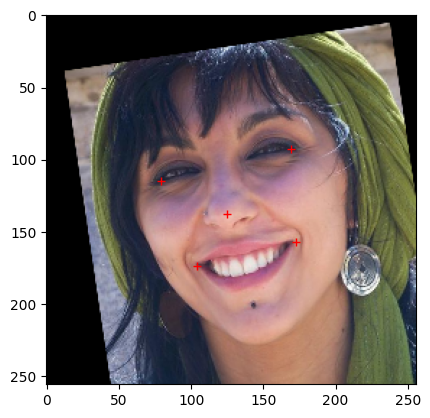

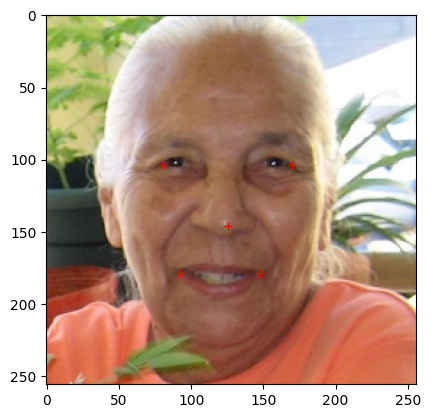

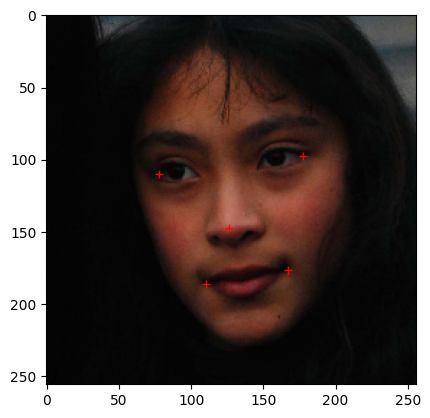

In [3]:

def visualise_pts(img, pts):
  import matplotlib.pyplot as plt
  plt.imshow(img)
  plt.plot(pts[:, 0], pts[:, 1], '+r')
  plt.show()

for i in range(3):
  idx = np.random.randint(0, images_train.shape[0])
  visualise_pts(images_train[idx, ...], pts_train[idx, ...])

# Calculating Prediction Error and exporting results

In [4]:
def euclid_dist(pred_pts, gt_pts):
  """
  Calculate the euclidean distance between pairs of points
  :param pred_pts: The predicted points
  :param gt_pts: The ground truth points
  :return: An array of shape (no_points,) containing the distance of each predicted point from the ground truth
  """
  import numpy as np
  pred_pts = np.reshape(pred_pts, (-1, 2))
  gt_pts = np.reshape(gt_pts, (-1, 2))
  return np.sqrt(np.sum(np.square(pred_pts - gt_pts), axis=-1))


In [5]:
def save_as_csv(points, location = '.'):
    """
    Save the points out as a .csv file
    :param points: numpy array of shape (no_test_images, no_points, 2) to be saved
    :param location: Directory to save results.csv in. Default to current working directory
    """
    assert points.shape[0]==554, 'wrong number of image points, should be 554 test images'
    assert np.prod(points.shape[1:])==5*2, 'wrong number of points provided. There should be 5 points with 2 values (x,y) per point'
    np.savetxt(location + '/results_task2.csv', np.reshape(points, (points.shape[0], -1)), delimiter=',')


In [2]:
# === Plot 6 additionl random training examples with landmarks overlaid ===
rng = np.random.default_rng(seed=42)
sample_idx = rng.choice(len(images)train), size=6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, idx in zip(axes.flat, sample_idx):
    ax.imshow(images_train[idx])
    pts = pts_train[idx]
    ax.scatter(pts[:, 0], pts[:, 1], s=80, c='lime', edgecolors='black',
               linewidths=1.5, zorder=3)
    # Annotate each landmark with its index
    for i, (x, y) in enumerate(pts):
        ax.annotate(str(i), (x, y), color='white', fontsize=12,
                    fontweight='bold',
                    xytext=(5, 5), textcoords='offset points')
    ax.set_title(f'Image #{idx}')
    ax.axis('off')

fig.tight_layout()
plt.savefig(f'{FIGURES_DIR}/01_sample_images_with_landmarks.png',
            dpi=120, bbox_inches='tight')
plt.show()

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 21)